In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sharathchandrarevu/dsb-project/Gold 100years.csv
/kaggle/input/datasets/sharathchandrarevu/dsb-project/Brent Oil.csv
/kaggle/input/datasets/sharathchandrarevu/dsb-project/silver 100 years.csv
/kaggle/input/datasets/sharathchandrarevu/currency/swift_currency_tracker_all_reports.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

# Display bigger charts
plt.rcParams['figure.figsize'] = (14,6)

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input/datasets/sharathchandrarevu/dsb-project'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sharathchandrarevu/dsb-project/Gold 100years.csv
/kaggle/input/datasets/sharathchandrarevu/dsb-project/Brent Oil.csv
/kaggle/input/datasets/sharathchandrarevu/dsb-project/silver 100 years.csv


In [4]:
brent = pd.read_csv('/kaggle/input/datasets/sharathchandrarevu/dsb-project/Gold 100years.csv')
gold = pd.read_csv('/kaggle/input/datasets/sharathchandrarevu/dsb-project/Brent Oil.csv')
silver = pd.read_csv('/kaggle/input/datasets/sharathchandrarevu/dsb-project/silver 100 years.csv')

In [5]:
print(brent.head())
print(brent.columns)

print(gold.head())
print(gold.columns)

print(silver.head())
print(silver.columns)

         Date  Value
0  01/01/1915  19.25
1  02/01/1915  19.25
2  03/01/1915  19.25
3  04/01/1915  19.25
4  05/01/1915  19.25
Index(['Date', 'Value'], dtype='object')
         Date  Value
0  01/01/1946  21.23
1  02/01/1946  21.35
2  03/01/1946  21.11
3  04/01/1946  22.79
4  05/01/1946  22.67
Index(['Date', 'Value'], dtype='object')
         Date  Value
0  01/01/1915   0.51
1  02/01/1915   0.51
2  03/01/1915   0.51
3  04/01/1915   0.51
4  05/01/1915   0.51
Index(['Date', 'Value'], dtype='object')


In [6]:
brent['Date'] = pd.to_datetime(brent['Date'])
gold['Date'] = pd.to_datetime(gold['Date'])
silver['Date'] = pd.to_datetime(silver['Date'])

# Rename price columns
brent.rename(columns={'Price':'Brent_Oil_Price'}, inplace=True)
gold.rename(columns={'Price':'Gold_Price'}, inplace=True)
silver.rename(columns={'Price':'Silver_Price'}, inplace=True)

In [7]:
display(brent.head())
display(brent.info())

,Date,Value
0,1915-01-01,19.25
1,1915-02-01,19.25
2,1915-03-01,19.25
3,1915-04-01,19.25
4,1915-05-01,19.25


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1336 non-null   datetime64[ns]
 1   Value   1336 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 21.0 KB


None

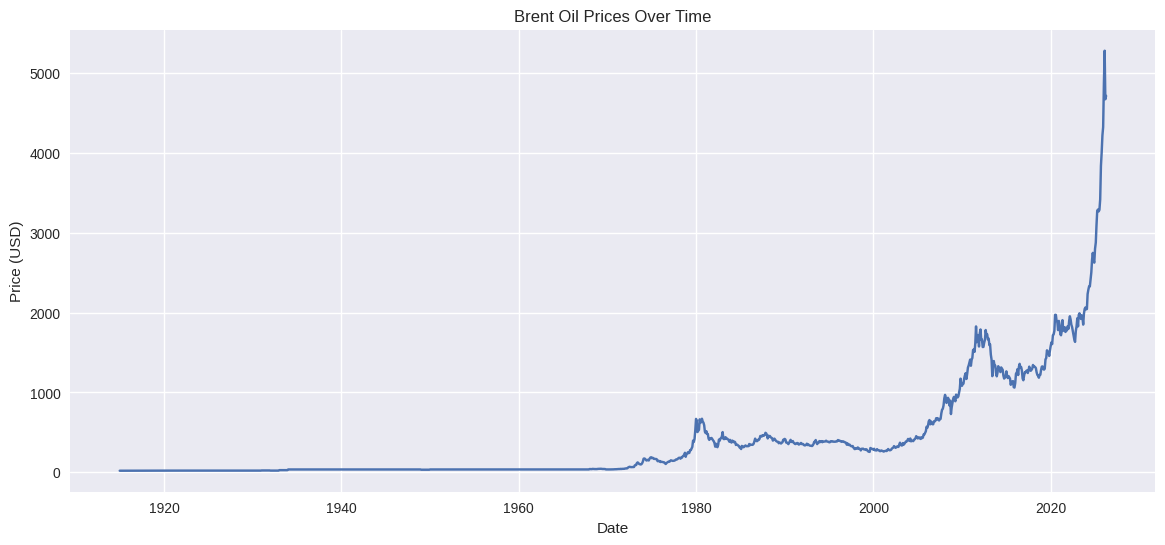

In [8]:
plt.plot(brent['Date'],
         brent['Value'])

plt.title('Brent Oil Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)

plt.show()

In [9]:
plt.savefig('brent_chart.png')

<Figure size 1400x600 with 0 Axes>

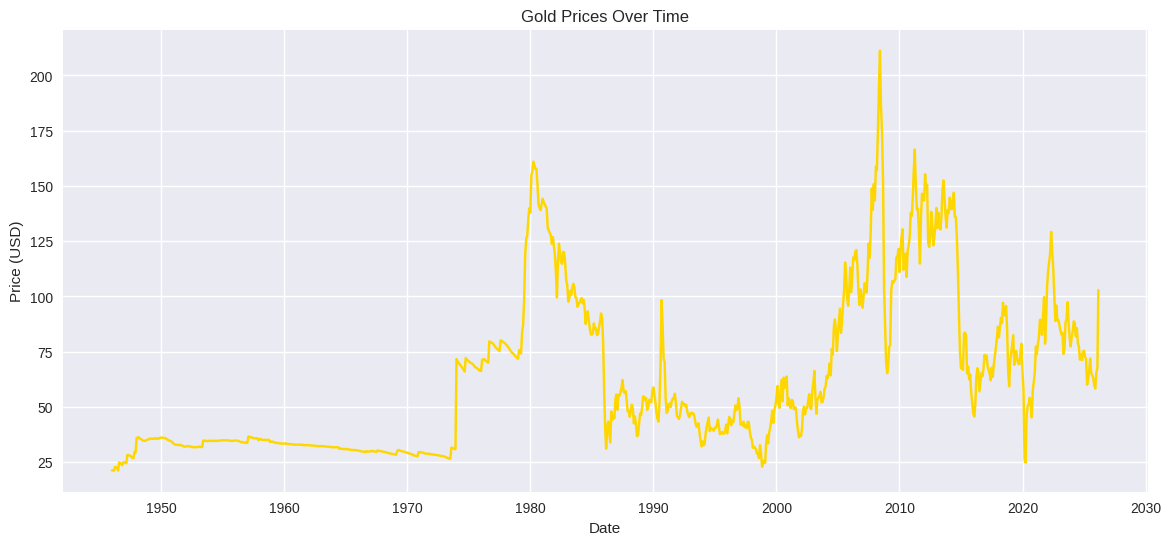

In [10]:
plt.figure(figsize=(14,6))

plt.plot(gold['Date'],
         gold['Value'],
         color='gold')

plt.title('Gold Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.grid(True)

plt.show()

In [11]:
plt.savefig('gold_chart.png')

<Figure size 1400x600 with 0 Axes>

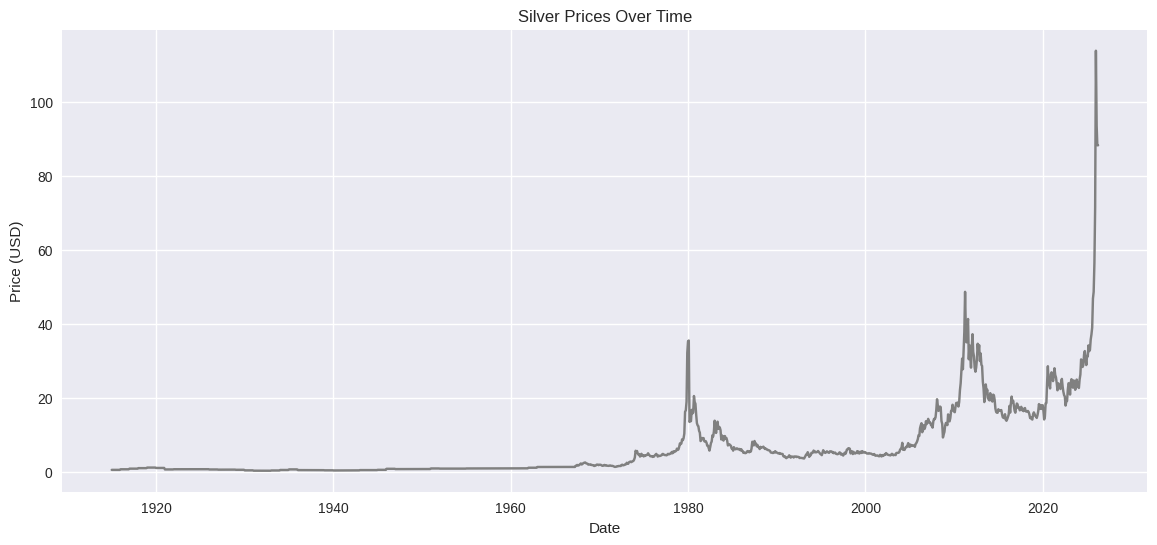

In [12]:
plt.figure(figsize=(14,6))

plt.plot(silver['Date'],
         silver['Value'],
         color='gray')

plt.title('Silver Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.grid(True)

plt.show()

In [13]:
plt.savefig('silver_chart.png')

<Figure size 1400x600 with 0 Axes>

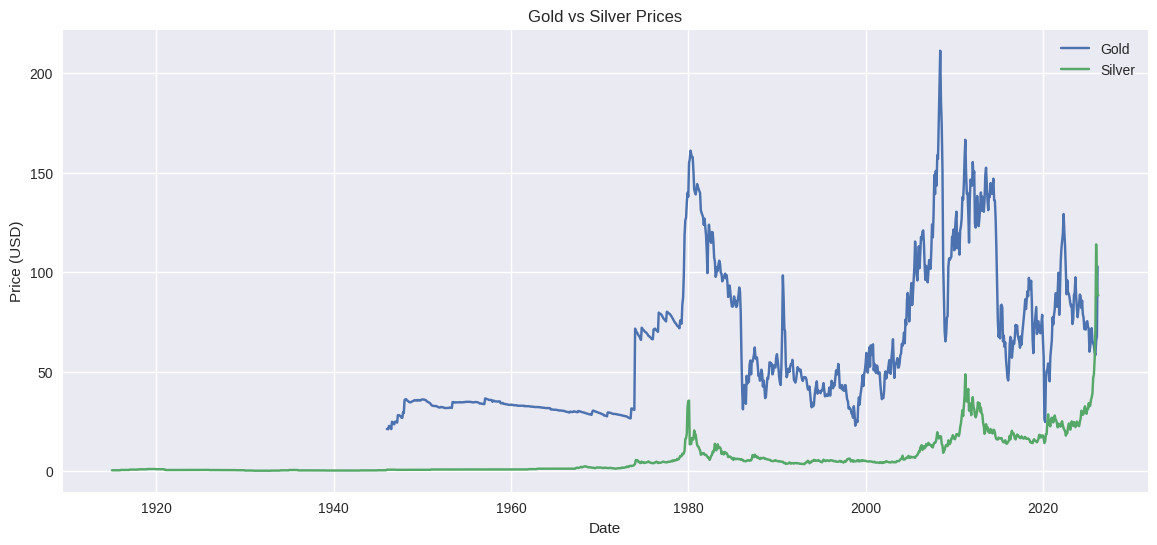

In [14]:
plt.figure(figsize=(14,6))

plt.plot(gold['Date'],
         gold['Value'],
         label='Gold')

plt.plot(silver['Date'],
         silver['Value'],
         label='Silver')

plt.legend()

plt.title('Gold vs Silver Prices')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.grid(True)

plt.show()

In [15]:
plt.savefig('gold_silver_chart.png')

<Figure size 1400x600 with 0 Axes>

In [16]:
brent['Year'] = brent['Date'].dt.year

In [17]:
annual_avg = brent.groupby('Year')['Value'].mean()

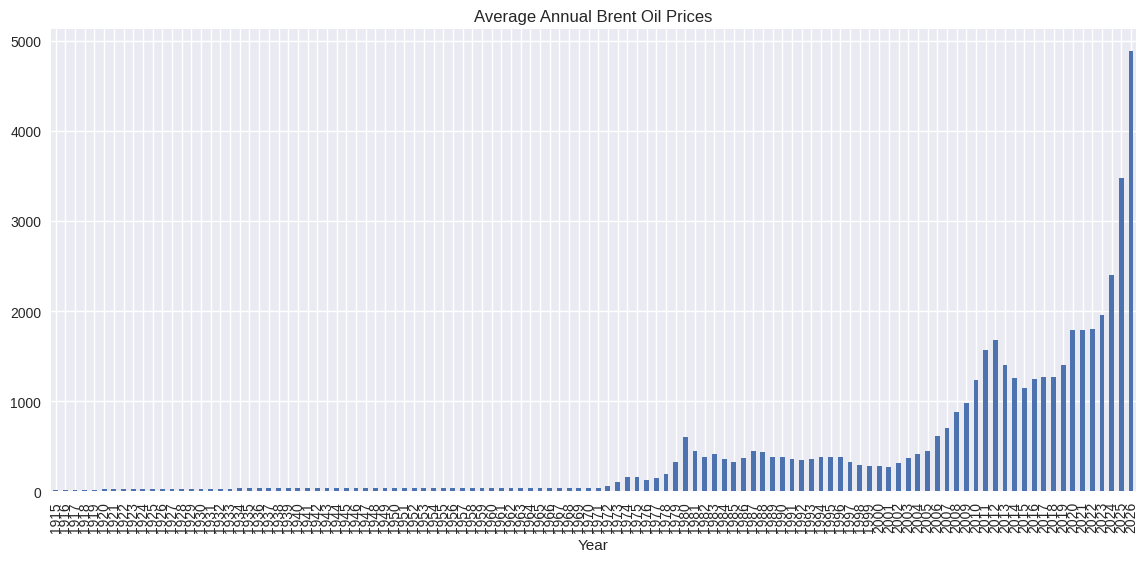

In [18]:
annual_avg.plot(kind='bar')

plt.title('Average Annual Brent Oil Prices')

plt.show()

In [19]:
plt.savefig('annual_average_chart.png')

<Figure size 1400x600 with 0 Axes>

In [20]:
latest_values = pd.DataFrame({
    'Commodity': ['Brent Oil', 'Gold', 'Silver'],
    'Latest Price': [
        brent['Value'].iloc[-1],
        gold['Value'].iloc[-1],
        silver['Value'].iloc[-1]
    ]
})

display(latest_values)

,Commodity,Latest Price
0,Brent Oil,4712.8906
1,Gold,102.8600
2,Silver,88.3600


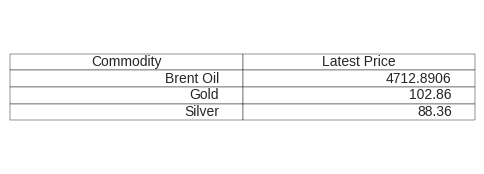

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,2))

ax.axis('off')

table = ax.table(
    cellText=latest_values.values,
    colLabels=latest_values.columns,
    loc='center'
)

plt.savefig('latest_values_table.png',
            bbox_inches='tight')

plt.show()

In [22]:
plt.savefig('latest_chart.png')

<Figure size 1400x600 with 0 Axes>

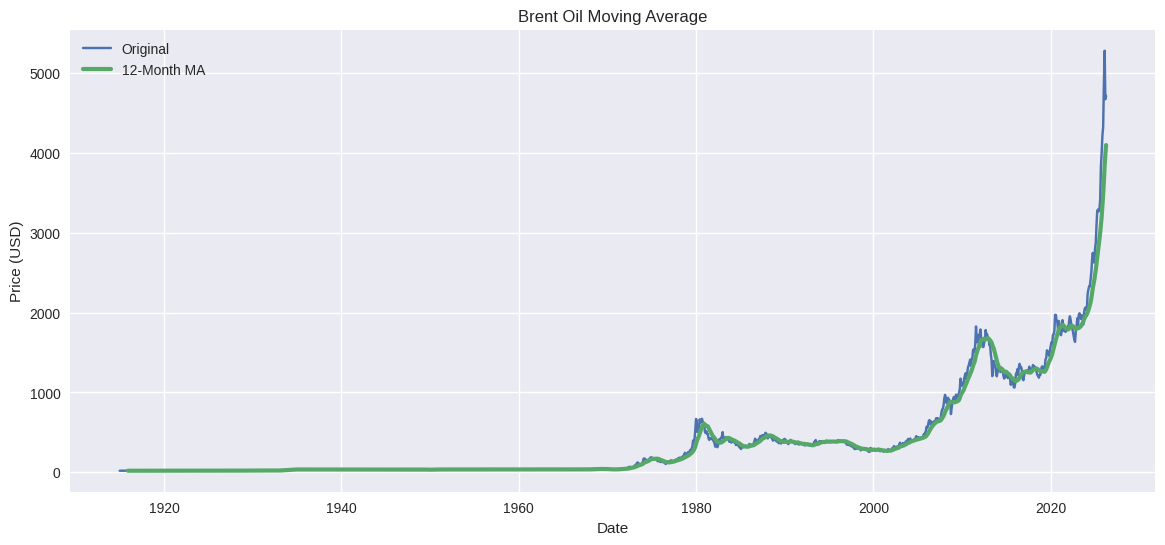

In [23]:
brent['MA_12'] = brent['Value'].rolling(12).mean()

plt.figure(figsize=(14,6))

plt.plot(brent['Date'],
         brent['Value'],
         label='Original')

plt.plot(brent['Date'],
         brent['MA_12'],
         label='12-Month MA',
         linewidth=3)

plt.legend()

plt.title('Brent Oil Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

plt.grid(True)

plt.show()

In [24]:
plt.savefig('moving_average_chart.png')

<Figure size 1400x600 with 0 Axes>

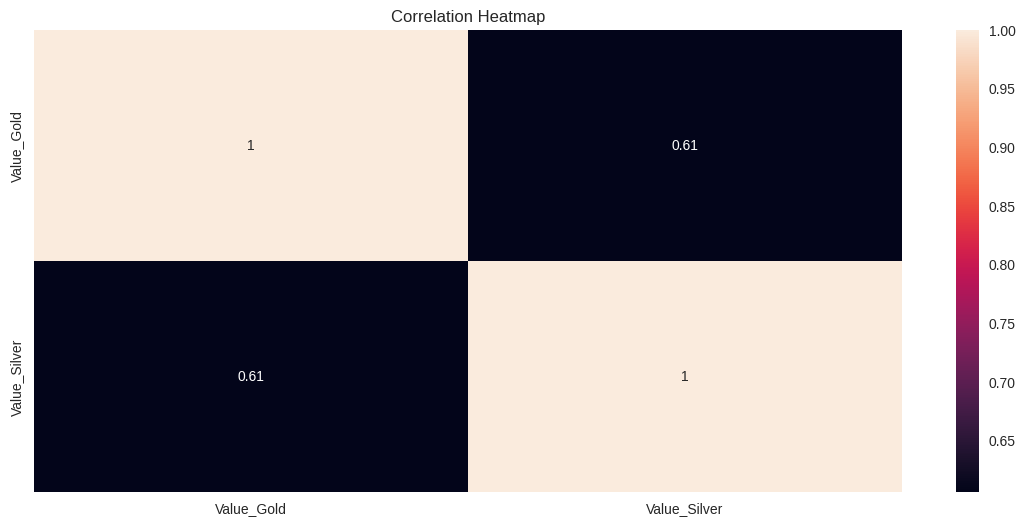

In [25]:
combined = pd.merge(
    gold[['Date','Value']],
    silver[['Date','Value']],
    on='Date',
    suffixes=('_Gold', '_Silver')
)

corr = combined[['Value_Gold','Value_Silver']].corr()

sns.heatmap(corr,
            annot=True)

plt.title('Correlation Heatmap')

plt.show()

In [26]:
plt.savefig('heatmap_chart.png')

<Figure size 1400x600 with 0 Axes>

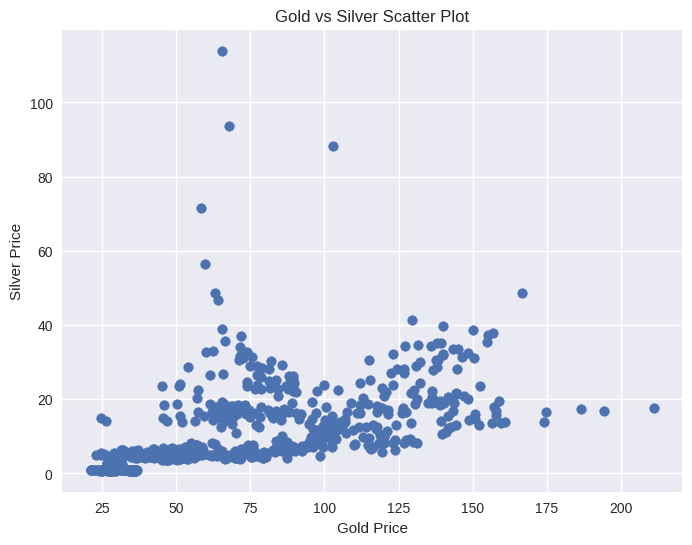

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(combined['Value_Gold'],
            combined['Value_Silver'])

plt.xlabel('Gold Price')
plt.ylabel('Silver Price')

plt.title('Gold vs Silver Scatter Plot')

plt.grid(True)

plt.show()

In [28]:
plt.savefig('scatter_plot_chart.png')

<Figure size 1400x600 with 0 Axes>

In [29]:
swift = pd.read_csv('/kaggle/input/datasets/sharathchandrarevu/currency/swift_currency_tracker_all_reports.csv')

In [30]:
print(swift.head())

   report_month     data_month source_report_name                metric  \
0  January 2026  December 2025        RMB Tracker  Global Payment Share   
1  January 2026  December 2025        RMB Tracker  Global Payment Share   
2  January 2026  December 2025        RMB Tracker  Global Payment Share   
3  January 2026  December 2025        RMB Tracker  Global Payment Share   
4  January 2026  December 2025        RMB Tracker  Global Payment Share   

           category currency_or_economy  value unit  rmb_global_rank   notes  
0  Currency Ranking                 USD  50.49    %              NaN  Rank 1  
1  Currency Ranking                 EUR  21.90    %              NaN  Rank 2  
2  Currency Ranking                 GBP   6.73    %              NaN  Rank 3  
3  Currency Ranking                 CAD   3.44    %              NaN  Rank 4  
4  Currency Ranking                 JPY   3.42    %              NaN  Rank 5  


In [31]:
print(swift.columns)

Index(['report_month', 'data_month', 'source_report_name', 'metric',
       'category', 'currency_or_economy', 'value', 'unit', 'rmb_global_rank',
       'notes'],
      dtype='object')


In [32]:
filtered = swift[swift['category'] == 'Currency Ranking']

In [33]:
latest = filtered.drop_duplicates(
    subset='currency_or_economy'
)

In [34]:
top10 = latest.sort_values(
    by='value',
    ascending=False
).head(10)

In [35]:
print(top10[['currency_or_economy', 'value']])

  currency_or_economy  value
0                 USD  50.49
1                 EUR  21.90
2                 GBP   6.73
3                 CAD   3.44
4                 JPY   3.42
5                 CNY   2.73
6                 HKD   1.68
7                 AUD   1.60
8                 SGD   1.33
9                 CHF   0.95


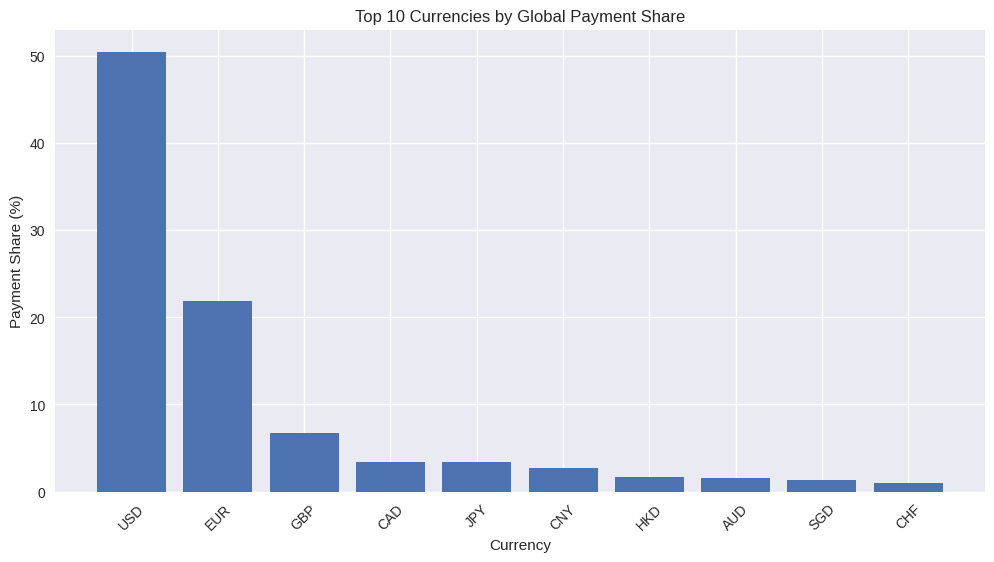

In [36]:
plt.figure(figsize=(12,6))

plt.bar(top10['currency_or_economy'],
        top10['value'])

plt.title('Top 10 Currencies by Global Payment Share')
plt.xlabel('Currency')
plt.ylabel('Payment Share (%)')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [37]:
plt.savefig('top10_currencies.png')

<Figure size 1400x600 with 0 Axes>